In [1]:
import pandas as pd

In [2]:
import plotly.express as px

In [4]:
df_apps = pd.read_csv('../Data/apps.csv')

In [5]:
df_apps.sample(3)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Android_Ver
4330,Taha Al Junaid Quran Mp3,LIFESTYLE,4.6,518,4.2,"50,000",Free,0,Everyone,Lifestyle,"March 25, 2017",2.3.3 and up
3567,Trimble DL,PRODUCTIVITY,4.2,133,7.9,"10,000",Free,0,Everyone,Productivity,"January 12, 2018",4.2 and up
6262,Sirens Fashion Style Game,FAMILY,4.3,2282,22.0,"500,000",Free,0,Everyone,Simulation,"February 20, 2018",4.0 and up


**Drop Columns**

In [6]:
df_apps.drop(['Last_Updated', 'Android_Ver'], axis=1, inplace=True)

**Drop NaN**

In [13]:
df_apps_clean = df_apps.dropna()

**Drop Duplicates**

In [ ]:
df_apps_clean.drop_duplicates(subset=['App', 'Type', 'Price'], inplace=True)
df_apps_clean.duplicated().any()

In [21]:
ratings = df_apps_clean.Content_Rating.value_counts()

In [26]:
ratings.values

array([6621,  912,  357,  305,    3,    1])

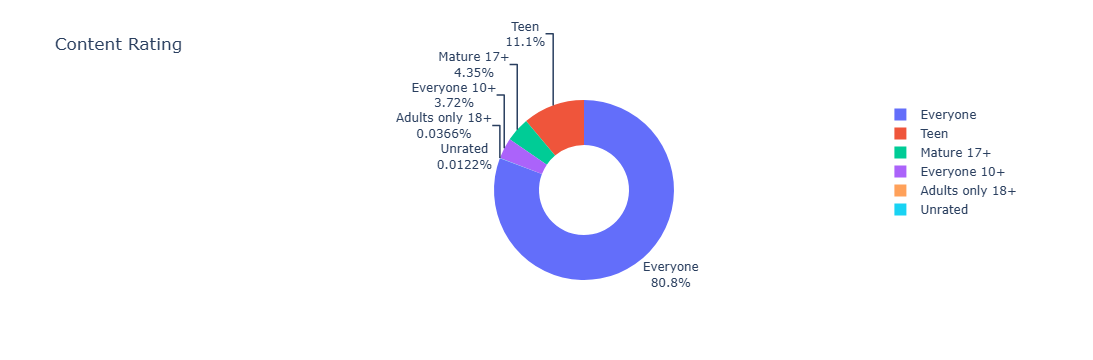

In [32]:
x = ratings.index
y = ratings.values

fig = px.pie(labels=x, values=y, names=x, hole=0.5, title="Content Rating")
fig.update_traces(textposition='outside', textinfo='percent+label')

fig.show()

---
**Convert to a Numeric Data Type**

In [ ]:
df_apps_clean.Installs = df_apps_clean.Installs.astype(str).str.replace(',','')
df_apps_clean.Installs = pd.to_numeric(df_apps_clean.Installs)

In [ ]:
df_apps_clean.Price = df_apps_clean.Price.astype(str).str.replace('$', '')
df_apps_clean.Price = pd.to_numeric(df_apps_clean.Price)

---
**Bar Charts**

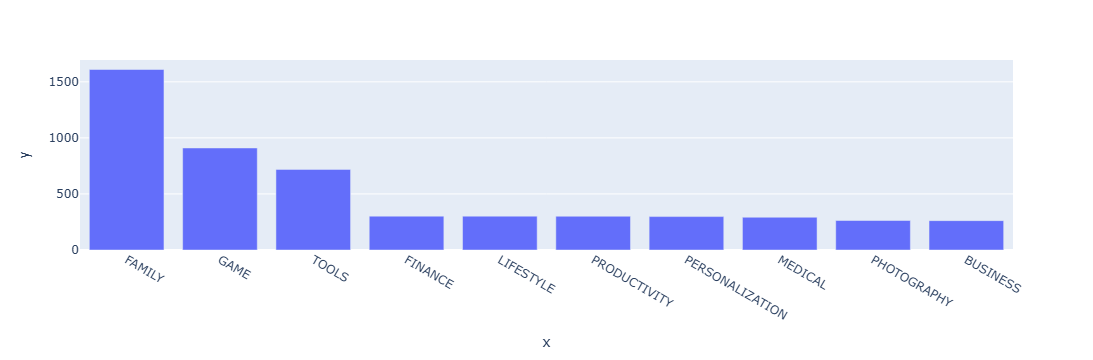

In [55]:
x = df_apps_clean.Category.value_counts()[:10].index
y = df_apps_clean.Category.value_counts()[:10].values

bar = px.bar(x=x,y=y)
bar.show()


---


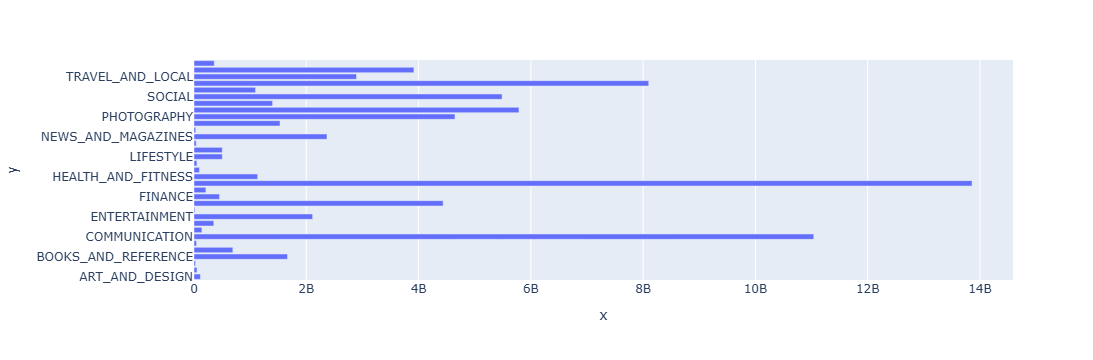

In [74]:
cat_installs = df_apps_clean.groupby('Category').agg({'Installs': pd.Series.sum})

y = cat_installs.index
x = cat_installs.Installs

fig = px.bar(x=x, y=y, orientation='h')
fig.show()

---

In [75]:
cat_number = df_apps_clean.groupby('Category').agg({'App': pd.Series.nunique})
cat_merge = pd.merge(cat_installs, cat_number, on='Category', how='inner')
cat_merge.head()

,Installs,App
Category,,
ART_AND_DESIGN,114233100,61
AUTO_AND_VEHICLES,53129800,73
BEAUTY,26916200,42
BOOKS_AND_REFERENCE,1665791655,169
BUSINESS,692018120,262


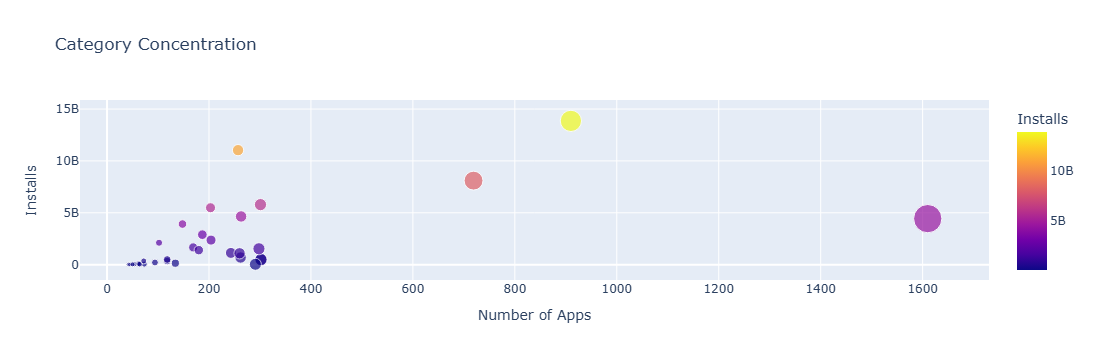

In [86]:
fig = px.scatter(cat_merge, 'App', 'Installs', size='App', hover_name= cat_merge.index, color='Installs', title='Category Concentration')
fig.update_layout(xaxis_title="Number of Apps", yaxis_title="Installs")
fig.show()

---

**Number of Genres**

In [106]:
st_df = df_apps_clean.Genres.str.split(';', expand=True).stack()
num_genres = st_df.value_counts()
len(num_genres)

53

---
**Free vs Paid Apps per Category**

In [108]:
free_vs_paid = df_apps_clean.groupby(['Category', 'Type'], as_index=False).agg({'App': pd.Series.count})

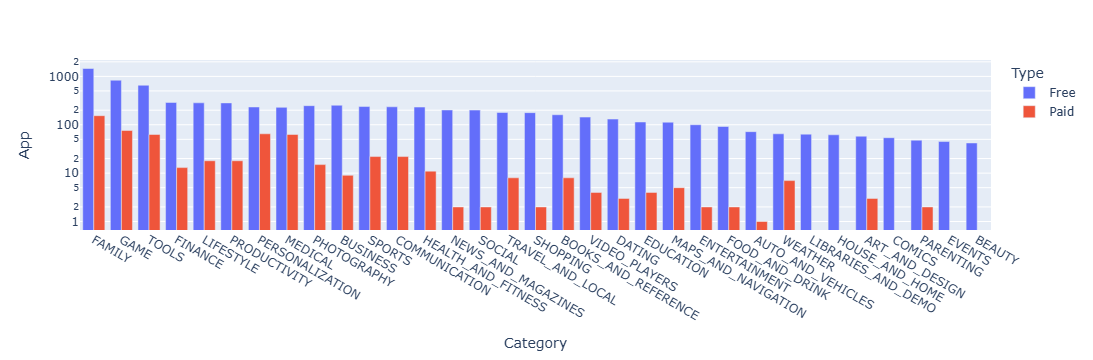

In [114]:
fig = px.bar(free_vs_paid, x='Category', y='App', barmode='group', color='Type')
fig.update_layout(xaxis={'categoryorder':'total descending'}, yaxis=dict(type='log'))
fig.show()